# Out-of-Sample Validation - May-June 2026 (Figure 7.12)

Reproduces **Section 5b** of `05_Report/forecasting_pipeline_report.md` and
**Figure 7.12** (`04_Outputs/forecast_validation_jun2026.png`) in the final report.

**What this does:** stress-tests the naive random-walk (RW) forecast - the same
baseline used as the reference model throughout Tier 1-3 - against actual spot
prices for May and June 2026, fetched after the fact via `yfinance`.

**Method:** last CSV observation = forecast origin. Point forecast uses a
log-normal random walk with drift:

```
forecast_h = P0 * exp(mu * h)
95% CI     = exp( ln(P0) + mu*h +/- 1.96 * sigma * sqrt(h) )
```

where `mu`, `sigma` are the mean/std of monthly log returns over the trailing
60 months (rolling window), `h` is the number of months ahead, and `P0` is the
last observed price. This is the naive i.i.d. CI used for this validation
table; the live Streamlit dashboard shows the tighter/wider GARCH(1,1)
heteroskedastic cone instead (see `garch_forecast_cone.png`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

try:
    import yfinance as yf
    HAS_YFINANCE = True
except ImportError:
    HAS_YFINANCE = False

plt.rcParams.update({'figure.figsize': (14, 5), 'axes.grid': True, 'grid.alpha': 0.3})
sns.set_style('whitegrid')

DATA_DIR   = Path('../../01_Raw_Data')
OUTPUT_DIR = Path('../../04_Outputs')

COLORS = {'Gold': '#FFB300', 'Silver': '#78909C', 'Brent': '#1565C0'}

print('yfinance available:', HAS_YFINANCE)

yfinance available: True


In [2]:
def load_monthly(filename, col):
    df = pd.read_csv(DATA_DIR / filename)
    df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
    df = df.rename(columns={'Value': col}).set_index('Date').sort_index()
    df.index = df.index.to_period('M').to_timestamp()
    df['log_p'] = np.log(df[col])
    df['ret'] = df['log_p'].diff()
    return df

ASSETS = {
    'Gold':   (load_monthly('gold100years.csv', 'gold'),     'gold'),
    'Silver': (load_monthly('silver100years.csv', 'silver'), 'silver'),
    'Brent':  (load_monthly('brentOil.csv', 'brent'),        'brent'),
}

for name, (df, col) in ASSETS.items():
    print(f'{name:8s}: origin={df.index[-1].date()}  P0={df[col].iloc[-1]:,.2f}')

Gold    : origin=2026-04-01  P0=4,712.89
Silver  : origin=2026-04-01  P0=88.36
Brent   : origin=2026-03-01  P0=102.86


## 1. Naive random-walk forecast + 95% CI

Forecast origin per asset = last observed month in the raw CSV (Gold/Silver:
April 2026, Brent: March 2026 - Brent's source lags one month). Horizon `h`
is the number of months from the origin to each validation target.

In [3]:
def rw_forecast(df, col, target_date, window=60):
    """Naive log-normal RW forecast + 95% CI, mu/sigma from trailing `window` months."""
    origin = df.index[-1]
    target = pd.Timestamp(target_date)
    h = (target.year - origin.year) * 12 + (target.month - origin.month)
    ret_window = df['ret'].tail(window)
    mu, sigma = ret_window.mean(), ret_window.std()
    P0 = df[col].iloc[-1]
    fc = P0 * np.exp(mu * h)
    lo = np.exp(np.log(P0) + mu * h - 1.96 * sigma * np.sqrt(h))
    hi = np.exp(np.log(P0) + mu * h + 1.96 * sigma * np.sqrt(h))
    return {'Asset': None, 'Period': target.strftime('%b %Y'), 'Date': target,
            'Origin': origin, 'Horizon_m': h, 'Forecast': fc, 'CI_lo': lo, 'CI_hi': hi}

VALIDATION_TARGETS = {
    'Gold':   ['2026-05-01', '2026-06-01'],
    'Silver': ['2026-05-01', '2026-06-01'],
    'Brent':  ['2026-04-01', '2026-05-01', '2026-06-01'],
}

rows = []
for name, targets in VALIDATION_TARGETS.items():
    df, col = ASSETS[name]
    for t in targets:
        row = rw_forecast(df, col, t)
        row['Asset'] = name
        rows.append(row)

forecast_df = pd.DataFrame(rows)
forecast_df

,Asset,Period,Date,Origin,Horizon_m,Forecast,CI_lo,CI_hi
0,Gold,May 2026,2026-05-01,2026-04-01,1,4790.549572,4381.425582,5237.876298
1,Gold,Jun 2026,2026-06-01,2026-04-01,2,4869.488208,4291.947506,5524.744973
2,Silver,May 2026,2026-05-01,2026-04-01,1,90.187630,73.993369,109.926183
3,Silver,Jun 2026,2026-06-01,2026-04-01,2,92.053063,69.579401,121.785561
4,Brent,Apr 2026,2026-04-01,2026-03-01,1,103.430987,85.747660,124.761062
5,Brent,May 2026,2026-05-01,2026-03-01,2,104.005144,79.780671,135.585097
6,Brent,Jun 2026,2026-06-01,2026-03-01,3,104.582488,75.582431,144.709513


## 2. Fetch actual spot prices (yfinance)

Monthly-average close for each validation month, using continuous front-month
futures tickers (`GC=F` Gold, `SI=F` Silver, `BZ=F` Brent). If `yfinance` is
unavailable or the fetch fails (offline environment), falls back to the
actuals already captured in the report (Section 5b) so the notebook stays
reproducible without network access - re-run with internet access to pull a
fresh snapshot.

In [4]:
TICKERS = {'Gold': 'GC=F', 'Silver': 'SI=F', 'Brent': 'BZ=F'}

# Fallback = actuals as reported in 05_Report/forecasting_pipeline_report.md, Section 5b
FALLBACK_ACTUALS = {
    ('Gold',   'May 2026'): 4590.0, ('Gold',   'Jun 2026'): 4309.0,
    ('Silver', 'May 2026'): 78.14,  ('Silver', 'Jun 2026'): 69.21,
    ('Brent',  'Apr 2026'): 102.46, ('Brent',  'May 2026'): 104.09, ('Brent', 'Jun 2026'): 89.04,
}

def fetch_actual_monthly(ticker, date):
    start = date.strftime('%Y-%m-%d')
    end = (date + pd.offsets.MonthEnd(1) + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
    hist = yf.download(ticker, start=start, end=end, progress=False)
    if hist.empty:
        return None
    close = hist['Close']
    return float(close.mean().iloc[0]) if hasattr(close.mean(), 'iloc') else float(close.mean())

actuals = []
for _, r in forecast_df.iterrows():
    val = None
    if HAS_YFINANCE:
        try:
            val = fetch_actual_monthly(TICKERS[r['Asset']], r['Date'])
        except Exception as e:
            print('  yfinance fetch failed for', r['Asset'], r['Period'], ':', e)
    if val is None:
        val = FALLBACK_ACTUALS[(r['Asset'], r['Period'])]
        print('  using fallback actual for', r['Asset'], r['Period'], ':', val)
    actuals.append(val)

forecast_df['Actual'] = actuals

In [5]:
forecast_df['Error_%'] = (forecast_df['Actual'] - forecast_df['Forecast']) / forecast_df['Actual'] * 100
forecast_df['In_95%_CI'] = forecast_df.apply(lambda r: r['CI_lo'] <= r['Actual'] <= r['CI_hi'], axis=1)

display_cols = ['Asset', 'Period', 'Forecast', 'Actual', 'Error_%', 'CI_lo', 'CI_hi', 'In_95%_CI']
validation_table = forecast_df[display_cols].round(2)
validation_table

,Asset,Period,Forecast,Actual,Error_%,CI_lo,CI_hi,In_95%_CI
0,Gold,May 2026,4790.55,4589.69,-4.38,4381.43,5237.88,True
1,Gold,Jun 2026,4869.49,4234.37,-15.00,4291.95,5524.74,False
2,Silver,May 2026,90.19,78.14,-15.42,73.99,109.93,True
3,Silver,Jun 2026,92.05,66.39,-38.66,69.58,121.79,False
4,Brent,Apr 2026,103.43,102.46,-0.94,85.75,124.76,True
5,Brent,May 2026,104.01,104.09,0.08,79.78,135.59,True
6,Brent,Jun 2026,104.58,84.62,-23.59,75.58,144.71,True


## 3. Figure 7.12 - Forecast vs. Actual

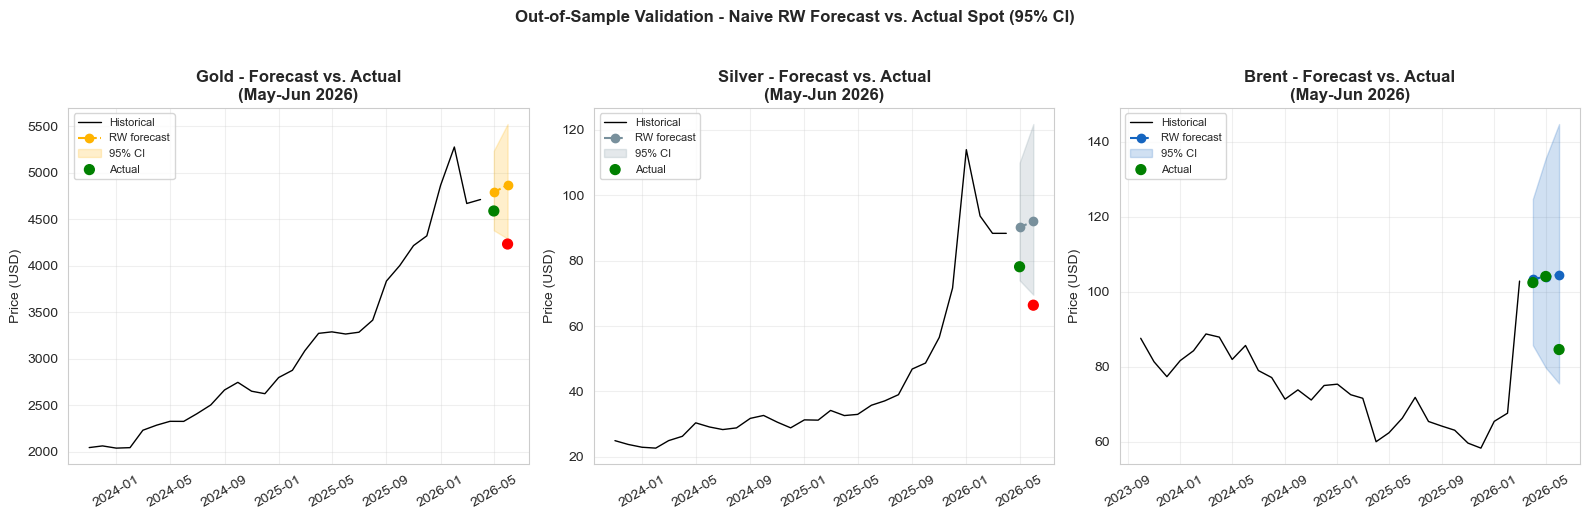

Saved -> ..\..\04_Outputs\forecast_validation_jun2026.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, name in zip(axes, ['Gold', 'Silver', 'Brent']):
    df, col = ASSETS[name]
    hist = df[col].iloc[-30:]
    ax.plot(hist.index, hist.values, color='black', linewidth=1.0, label='Historical')

    sub = forecast_df[forecast_df['Asset'] == name].sort_values('Date')
    ax.plot(sub['Date'], sub['Forecast'], color=COLORS[name], linewidth=1.5,
            linestyle='--', marker='o', label='RW forecast')
    ax.fill_between(sub['Date'], sub['CI_lo'], sub['CI_hi'], alpha=0.2,
                     color=COLORS[name], label='95% CI')

    in_ci = sub['In_95%_CI'].values
    ax.scatter(sub['Date'], sub['Actual'],
               color=['green' if ok else 'red' for ok in in_ci],
               zorder=5, s=50, label='Actual')

    ax.set_title(f'{name} - Forecast vs. Actual\n(May-Jun 2026)', fontweight='bold')
    ax.set_ylabel('Price (USD)')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Out-of-Sample Validation - Naive RW Forecast vs. Actual Spot (95% CI)',
             fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'forecast_validation_jun2026.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved ->', OUTPUT_DIR / 'forecast_validation_jun2026.png')

**Note:** ARIMA/VECM models were not re-evaluated here (their forecast origin
was April 2024 in Tier 1); re-running walk-forward validation to June 2026 is
recommended for a complete picture. This notebook only reproduces the naive
RW baseline shown in Figure 7.12 / Section 5b.